# Gradient Descent with Logistic Regression

## Defaulting on loans

Suppose we want to predict whether someone will default on their loan based on their income and the amount that they borrowed.

We will look at the dataset Default_Data.

In [140]:
#------------------------
# Import package
#------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm

# Plot style
plt.style.use('seaborn-whitegrid')

#------------------------
# Make dataframe
#------------------------

# Creates a dataframe from file called linearRegressionData.csv
df = pd.read_csv('Default-Data-New.csv')
#df = df.drop('Unnamed: 0', 1)
# df = df.dropna()
# df = df.drop(0)

#df.to_csv('Default-Data-New.csv', index = False)

# Prints first 5 lines of data
print(df.head(5))

# Print basic stats on data
print(df.describe())

   loan_amount  income  status
0       516500    9600       0
1       126500    1740       0
2       216500    3420       0
3       266500    5400       0
4       276500    5160       0
        loan_amount         income        status
count  1.000000e+04   10000.000000  10000.000000
mean   3.330090e+05    6929.292000      0.119600
std    1.871450e+05    5397.180336      0.324509
min    2.650000e+04       0.000000      0.000000
25%    1.965000e+05    3780.000000      0.000000
50%    2.965000e+05    5820.000000      0.000000
75%    4.365000e+05    8460.000000      0.000000
max    3.006500e+06  114900.000000      1.000000


Let us plot the data.

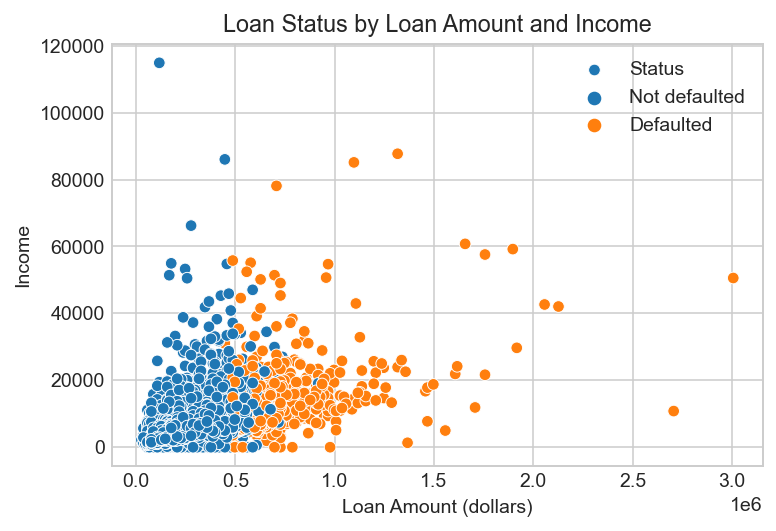

In [141]:
#------------------------
# Create plot
#------------------------

# Make figure size
fig = plt.figure(dpi = 140)

# Plot df data
sns.scatterplot(data=df, hue='status', x='loan_amount', y='income')

# Label figure
plt.xlabel('Loan Amount (dollars)')
plt.ylabel('Income')
plt.title('Loan Status by Loan Amount and Income')

# Add legend
plt.legend(['Status','Not defaulted', 'Defaulted'])

# Uncommment to save figure
plt.savefig('loanStatus.pdf', bbox_inches='tight', dpi= 300)
 
# Show the plot
plt.show()

We can use both logistic and linear regression here to see how they differ along with plotting the data.

In [142]:
# With sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

#------------------------
# Build logistic regression model using loan amount and income as predictors
#------------------------

# Split data into predictors x and output y
# Make list of predictors from dataset
predictors = ['loan_amount', 'income']
x = df[predictors]
y = df['status']

print('Number with status 1 is', np.count_nonzero(y.values))

#statusPredLogReg = LogisticRegression().fit(x, y)
statusPredLinReg = LinearRegression().fit(x, y)

# Run linear regression program, output is heightPred
statusLogRegModel = LogisticRegression(penalty = 'l2', C=1000, solver='liblinear', tol=0.01).fit(x, y)
statusLinRegModel = LinearRegression().fit(x, y)

# Print out thetas
#print('theta0 =', heightPred.intercept_)
#print('theta1 =', heightPred.coef_)

# Print out predictions for values in x
#print(heightPred.predict(x))

Number with status 1 is 1196


Now, we will plot our data and our two regression lines: 1) logistic regression, 2) linear regression.

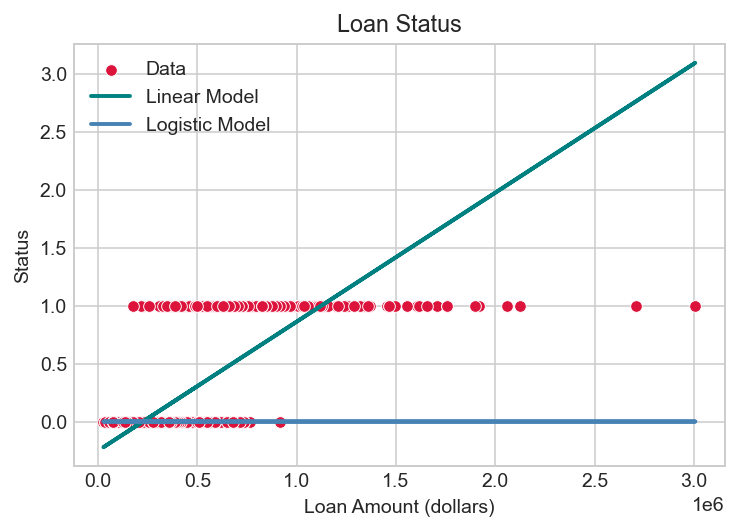

In [147]:
# Plot both the data and the new line

statusPred_LinReg = statusLinRegModel.predict(x)
statusPred_LogReg = statusLogRegModel.predict(x)

#print(statusPred_LogReg)
#print(np.count_nonzero(statusPred_LogReg))


# Make figure size
fig = plt.figure(dpi = 140)

# Plot data
sns.scatterplot(data=df, x='loan_amount', y='status', color='crimson', label = 'Data')
#df.plot(x = 'loan_amount', y = 'status', kind = 'scatter', color = 'crimson', label = 'Data')
# Plot linear model
plt.plot(df['loan_amount'], defaultPred_LinReg, color = 'teal', linewidth = 2, label = 'Linear Model')
# Plot logistic model
plt.plot(df['loan_amount'], defaultPred_LogReg, color = 'steelblue', linewidth = 2, label = 'Logistic Model')

# Label axes + title
plt.xlabel('Loan Amount (dollars)')
plt.ylabel('Status')
plt.title('Loan Status')

# Add legend
plt.legend()
 
# Show the plot
plt.show()

## Using Gradient Descent for Logistic Regression

In  general, if we have $N$ observations and two categories, so $y^i$ is 0 or 1, we can compactly write ${\ell}$, our objective function, as:

$$\begin{eqnarray}
{\ell} (\boldsymbol{\theta})  &=& \sum_{i=1}^N \left[{ y^i \log p({\bf x}^i; \boldsymbol{\theta}{\theta}) + (1 - y^i) \log(1 - p({\bf x}^i; \boldsymbol{\theta})}\right] \\
&=& \sum_{i=1}^N \left[{ y^i \boldsymbol{\theta}^T {\bf \tilde{x}}^i - \log\left({1 + e^{\boldsymbol{\theta}^T {\bf \tilde{x}}^i } }\right) }\right].
\end{eqnarray}$$

### Exercise 1

Work through the calculation to show how we get the equation above.

### Exercise 2

The *decision boundary* is the line in the state space of the input variables that corresponds to 

$$ P(Y = 1 | X = {\bf x}; \boldsymbol{\theta}) = 0.5. $$

Show that this is equivalent to the identity:

$$ \boldsymbol{\theta}^T{\bf \tilde{x}} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_D x_D = 0.$$

Modify the code above so that it plots the decision boundary on top of the scatter plot of loan amount versus income.

In [133]:
# Insert code here

You should get something like the graph below.  Notice that the decision line is nearly vertical.  What does this tell you about the influence of income on the probability of defaulting?

In [134]:
# Put our code here

### Exercise 3 - Logistic Regression and Gradient Descent  

Now, let us put this idea to work. The idea is to use gradient descent to implement logistic regression in order to solve a classification problem.

**Data Description**

The data is \textcolor{red}{on github give link} in a folder called AdmissionData.

Your mission is to create a model that will estimate the probability of being admitted to a highly ranked college based on GRE scores and GPA.  You have a list of scores for $N$ students (the inputs, ${\bf x}^{i}$) and you know whether or not they are admitted (the outputs, $y^{i}$, where a value of "1" means "admitted", and "0" means "not admitted").  We call this list the "training data" since we use it to find the parameters of the model, i.e. to train the model.

The data is formatted as three columns, where the first column is the outputs $y^{i}$, and the next two columns are the inputs, ${\bf x}^{i}$, where the second column gives all GRE test scores, and the third column contains the GPA.

**Plot the data**

Before using Gradient Descent, we will plot the data using different symbols to represent the two classes.

Load the data for the training examples onto your workspace, and generate
a scatter plot of the second column (GRE) against the third column (GPA) using a one color if they were admitted (if there is a 1 in the first column), and a different color if they were not admitted (if there is a 0 in the first column).

Your plot should look like the following:

   admit  gre   gpa
0      1  800  4.00
1      1  560  2.98
2      0  440  3.22
3      1  760  4.00
4      1  700  4.00
           admit         gre        gpa
count  61.000000   61.000000  61.000000
mean    0.540984  611.803279   3.453115
std     0.502453  120.242924   0.390698
min     0.000000  340.000000   2.420000
25%     0.000000  540.000000   3.200000
50%     1.000000  600.000000   3.530000
75%     1.000000  700.000000   3.730000
max     1.000000  800.000000   4.000000


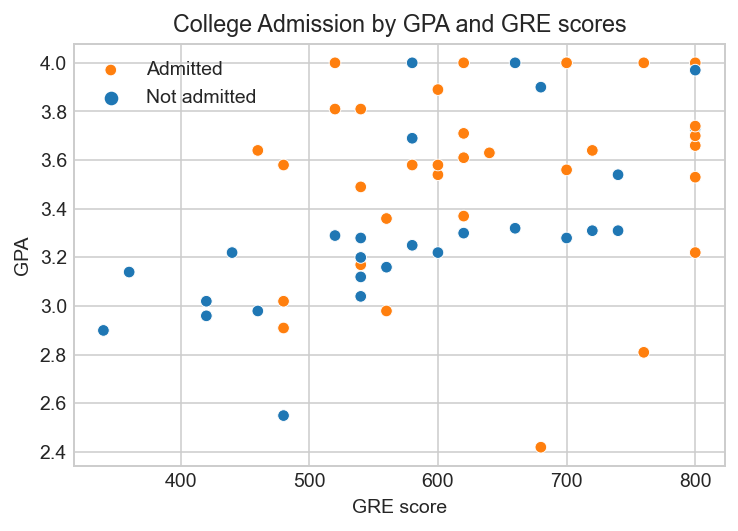

In [136]:
#------------------------
# Import package
#------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm

# Plot style
plt.style.use('seaborn-whitegrid')

#------------------------
# Make dataframe
#------------------------

# Creates a dataframe from file called linearRegressionData.csv
df = pd.read_csv('Admission-Data-Rank.csv')

# Prints first 5 lines of data
print(df.head(5))

# Print basic stats on data
print(df.describe())

#------------------------
# Create plot
#------------------------

# Make figure size
fig = plt.figure(dpi = 140)

# Plot df data
sns.scatterplot(data=df, hue='admit', x='gre', y='gpa')

# Label figure
plt.xlabel('GRE score')
plt.ylabel('GPA')
plt.title('College Admission by GPA and GRE scores')

# Add legend
plt.legend(['Admitted', 'Not admitted'])

# Uncommment to save figure
#plt.savefig('admission.pdf', bbox_inches='tight', dpi= 300)
 
# Show the plot
plt.show()

**The minimization problem**

We want to maximize the log likelihood function, so the objective function that we want to *minimize* is the negative of the log likelihood, whose partial derivatives we calculated in the equation above.

The update rule is 

$$
\boldsymbol{\theta}^{(t+1)}=\boldsymbol{\theta}^{(t)}-\gamma^{(t)}  \nabla (- \ell) =\boldsymbol{\theta}^{(t)}+\gamma^{(t)}  \nabla ( \ell)
$$

Here, we are writing $\boldsymbol{\theta}$, the gradient vector, $\nabla \ell$ and the input vector, ${\bf x}^{(i)}$, as *column* vectors. 

**Implementation**

The first thing to do is to add a "1" to each input vector, giving us an $N \times 3$ matrix for the inputs.

\textcolor{red}{Add implementation using Gradient Descent}

Once the algorithm has converged, use your value of $\boldsymbol{\theta}$ to draw the line that best separates the admitted points from the non-admitted points.  This line is called the *decision boundary* for the classification problem, and is given as the points that would be equally likely to be admitted as not admitted:

$$\begin{equation}
P(Y=1\vert {\bf x}; \boldsymbol{\theta}) =  0.5\;  \Leftrightarrow \; \boldsymbol{\theta}^T {\bf \tilde{x}} = 0 
\end{equation}$$

So, plotting the decision boundary is equivalent to plotting the line $\boldsymbol{\theta}^T {\bf \tilde{x}} =
\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$. You should get a plot that looks something like this

In [137]:
# Make figure \includegraphics[width = .7\textwidth]{LectureNotes/Figures/Lecture4/DecisionLine_CollegeAdmissions.png}

**Record your observations** by answering the following questions:

1. What is the final $\boldsymbol{\theta}$ value? How many iterations were required for convergence?
2. What is the probability that a student with a score of 680 on the GRE and a GPA of 3.5 will be admitted? 

In [138]:
# Insert code to answer questions here

### Exercise 4

Suppose we collect data for a group of students in a statistics class with variables $x_1 = $ hours studied and
$x_2 = $ undergrad GPA, and output $y = $ receive an A (1 or 0).  We fit a logistic regression and produce estimated coefficients $\theta_0 = -6$, $\theta_1 = 0.05$, $\theta_2 = 1$.

1. Estimate the probability that a student who studies for 40 h and has an undergrad GPA of 3.5 gets an A in the class.
2. How many hours would the student in part (a) need to study to have a 50\% chance of getting an A in the class?

--------

Solution

--------

1. Based on the coefficients, the model is
    $$ P(Y = 1 | x_1 = 40, x_2 = 3.5) = \frac{1}{1 + e^{-(-6 + (0.05)(40) + 3.5)}} = \frac{1}{1 + e^{0.5}} \approx 0.38
    $$
    so the student has a 38\% chance of getting an A.
2. To have a 50\% chance of getting an A, we solve for $x$ in:
    $$P(Y = 1 | x_1 = x, x_2 = 3.5) = .5 \Leftrightarrow
    \frac{1}{1 + e^{-(-6 + 0.05 x + 3.5)}} = \frac{1}{2}\Rightarrow 1 = e^{-(-2.5 + 0.05 x)} \Rightarrow x = 50.
    $$
    so the student would have to study for 50 hours.  